## Libraries Used

- For this analysis, I used the following Python libraries:

**pandas:** 
         For data manipulation and analysis. This includes loading the dataset, cleaning missing values, standardizing categorical data, aggregating revenue, and performing calculations such as total and average revenue per customer.

**seaborn:** 
         For creating statistical visualizations. I used it to generate histograms, boxplots, scatter plots, countplots, and line plots to explore trends, distributions, and correlations.

**matplotlib.pyplot:**
        For customizing visualizations and enhancing readability. I used it to add titles, axis labels, legends, rotate x-axis labels, set figure sizes, and overlay additional plot elements like regression lines.

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data:
- I load data from csv file by using pandas and give name to dataframe as **df**

In [3]:
df = pd.read_csv("product_sales.csv")

## Initial Exploration

After importing the necessary libraries, the dataset was loaded using pandas.
I used the following methods to understand the dataset structure and contents:

**df.head()** — Displayed the first few rows of the dataset to verify successful loading and preview column names and data types.

**df.info()** — Provided a concise summary including column names, data types, and non-null counts. This helped identify missing values and understand the schema.

**df.describe()** — Generated basic descriptive statistics (mean, median, standard deviation, etc.) for numerical columns, giving an overview of the data distribution.

**df.shape** — Returned the number of rows and columns ((15000, 8)), confirming the dataset size.

**Observation:**
The dataset contains 15,000 rows and 8 columns related to weekly sales, customer information, and sales methods. Some missing values were identified in the revenue column, and categorical columns like sales_method required cleaning for consistent naming.

In [4]:
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

   week  sales_method  ... nb_site_visits      state
0     2         Email  ...             24    Arizona
1     6  Email + Call  ...             28     Kansas
2     5          Call  ...             26  Wisconsin
3     4         Email  ...             25    Indiana
4     3         Email  ...             28   Illinois

[5 rows x 8 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB
None
   

## Handling Missing Values

The revenue column had some missing values (NaN).

Since the revenue distribution was right-skewed, I decided to fill the missing values with the median instead of the mean.
This helps to reduce the influence of extreme high values (outliers).

In [5]:
df['revenue'].fillna(df['revenue'].median(), inplace=True)

## Checking Missing Values

Using the `df.isnull().sum()` function, I identified missing values in each column.

All columns had complete data.

In [6]:
df.isnull().sum()

week                 0
sales_method         0
customer_id          0
nb_sold              0
revenue              0
years_as_customer    0
nb_site_visits       0
state                0
dtype: int64

## Checking for Duplicates

To ensure data quality, I used:
`df.duplicated().sum()`

The result showed no duplicate rows, confirming that all records were unique.

In [7]:
df.duplicated().sum()

0

## Fixing Categorical Inconsistencies

During data validation, I found that the sales_method column contained inconsistent text labels such as  "email", and "em + call".
These variations referred to the same category “Email” or “Email + Call” but were entered differently due to manual data entry.
After correction, the column contained three clean and consistent categories:

Email

Call

Email + Call

In [8]:
df['sales_method'].replace('em + call','Email + Call', inplace=True)
df['sales_method'].replace('email','Email',inplace=True)
df['sales_method'].unique()

array(['Email', 'Email + Call', 'Call'], dtype=object)

## Exploratory Analysis — Single Variable (Sales Method)

I analyzed the distribution of the sales methods to understand how many customers were reached through each approach.

To do this, I used the `value_counts()` function and visualized the result using a Seaborn catplot (count plot).

**Findings:**

- Email was the most frequently used sales method, followed by Call and Email    + Call.

- This suggests that the company relies heavily on email-based outreach for most customer interactions.

- However, the combined Email + Call method, though less frequent, may have higher revenue potential (to be checked in later analysis).

Email           7466
Call            4962
Email + Call    2572
Name: sales_method, dtype: int64


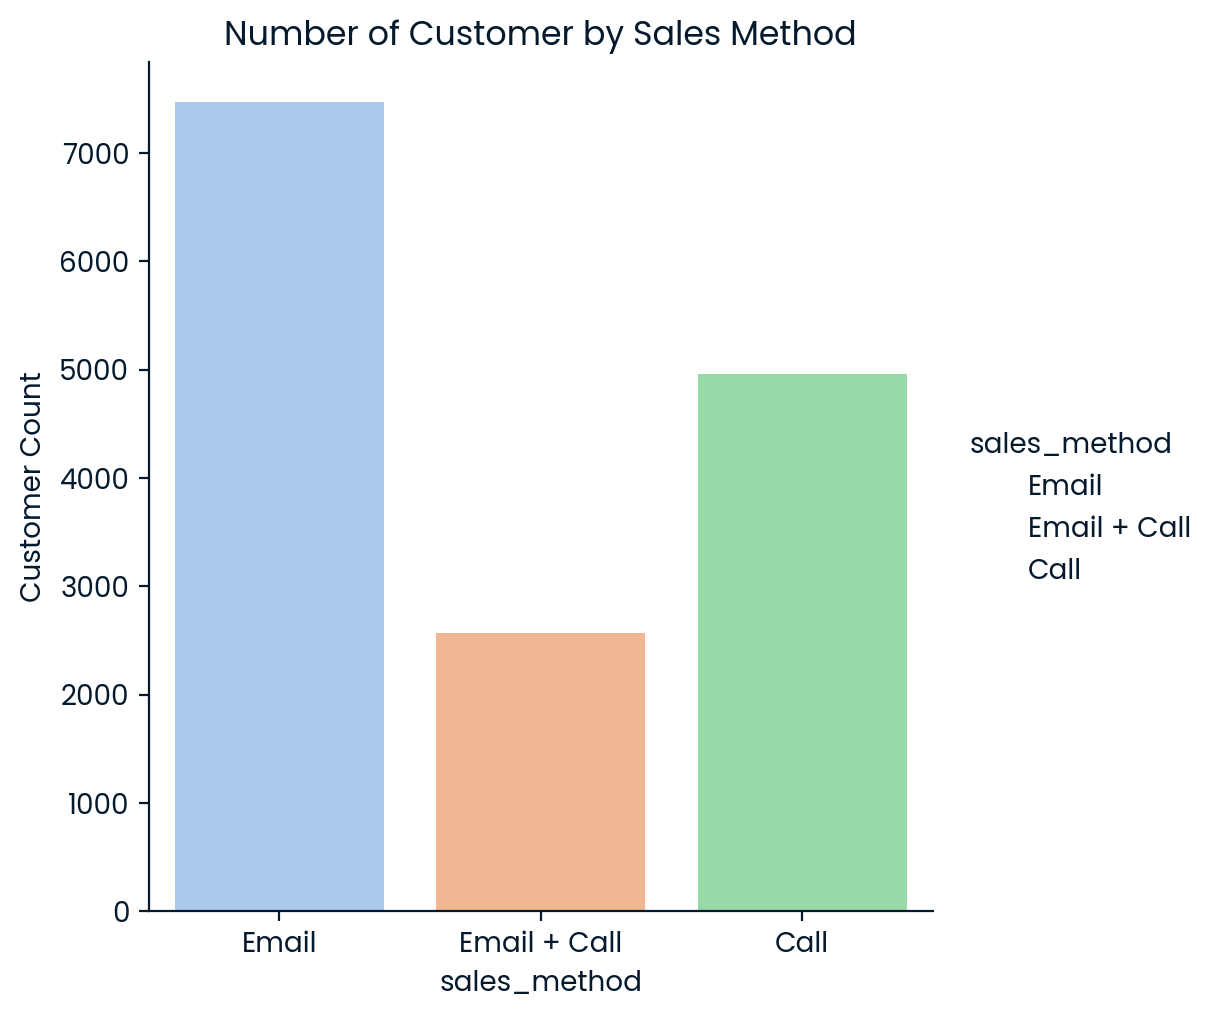

In [13]:
c=df['sales_method'].value_counts()
print(c)
sns.catplot(data =df, x='sales_method', kind='count', palette="pastel")
plt.title("Number of Customer by Sales Method")
plt.ylabel("Customer Count")
plt.show()

## Revenue by Sales Method

To understand how each sales method contributes to total and average revenue, I grouped the data by sales_method and calculated both the sum and mean of revenue.

The results were visualized using Seaborn catplots (bar charts) to compare total  revenue for each method.

**Findings:**

- The *Email* method generated the highest total revenue, indicating it reached the largest number of customers.

- The *Email + Call* method produced the highest average revenue per customer, suggesting it may be more effective for higher-value sales.

- The *Call* method had the lowest total and average revenue, making it less efficient compared to the others.

- These insights help the business decide whether to focus more on **Email + Call** for premium clients and **Email** for broad outreach.

                    sum        mean
sales_method                       
Call          243762.99   49.125955
Email         721005.83   96.571903
Email + Call  439492.19  170.875657


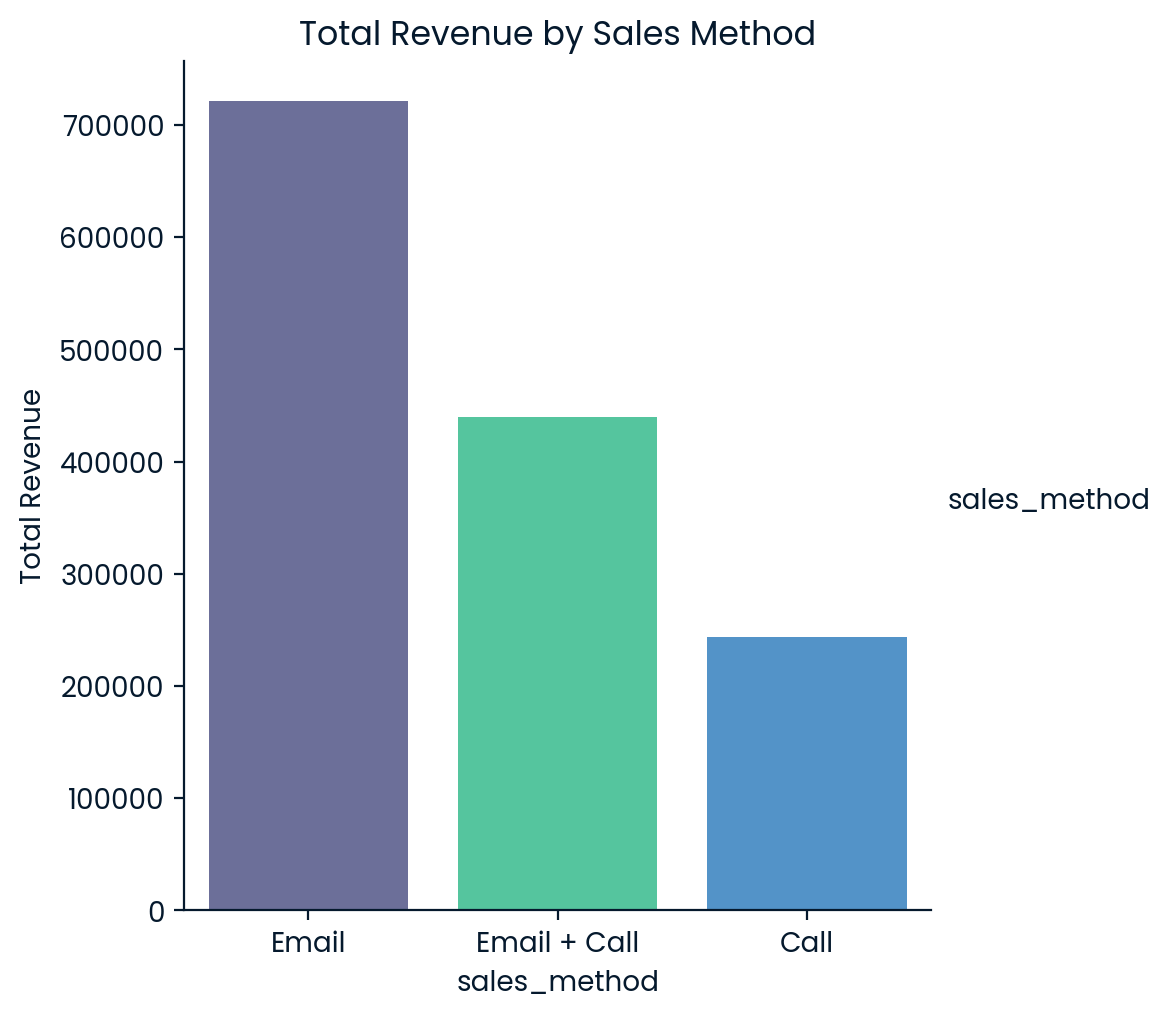

In [14]:
s_m_r = df.groupby('sales_method')['revenue'].agg(['sum','mean'])
print(s_m_r)

sns.catplot(data=df, x='sales_method', y='revenue', kind='bar', estimator=sum,hue='sales_method',ci=None)
plt.title("Total Revenue by Sales Method")
plt.ylabel("Total Revenue")
plt.show()

## Revenue by State

To analyze geographic performance, I grouped the dataset by state and calculated the total revenue for each region:

This was visualized with a bar chart using Seaborn’s catplot to highlight which states contribute the most to overall revenue.

**Findings:**

- The chart shows clear variation in total revenue by state.

- A few states stand out as top performers, contributing significantly higher revenue compared to others.

- This suggests that marketing or sales efforts in those high-performing regions are more effective, or that customer demand is stronger there.

- States with lower revenue could be targeted for sales strategy improvements or additional promotional campaigns.

             state    revenue
4       California  172944.39
42           Texas  113275.45
31        New York   89149.74
8          Florida   84632.75
12        Illinois   56318.85
37    Pennsylvania   55622.85
34            Ohio   52127.94
21        Michigan   47288.81
9          Georgia   46021.91
32  North Carolina   41013.65
29      New Jersey   39391.03
45        Virginia   36076.37
13         Indiana   33040.77
46      Washington   32725.39
41       Tennessee   30558.97
2          Arizona   29528.18
24        Missouri   28096.92
20   Massachusetts   27373.59
19        Maryland   24400.32
48       Wisconsin   23600.49
22       Minnesota   22874.14
36          Oregon   22414.83
39  South Carolina   22328.67
17       Louisiana   21735.67
5         Colorado   21156.48
0          Alabama   20657.86
16        Kentucky   19945.63
35        Oklahoma   18775.65
6      Connecticut   17426.65
14            Iowa   14962.63
23     Mississippi   13886.49
15          Kansas   13105.45
43        

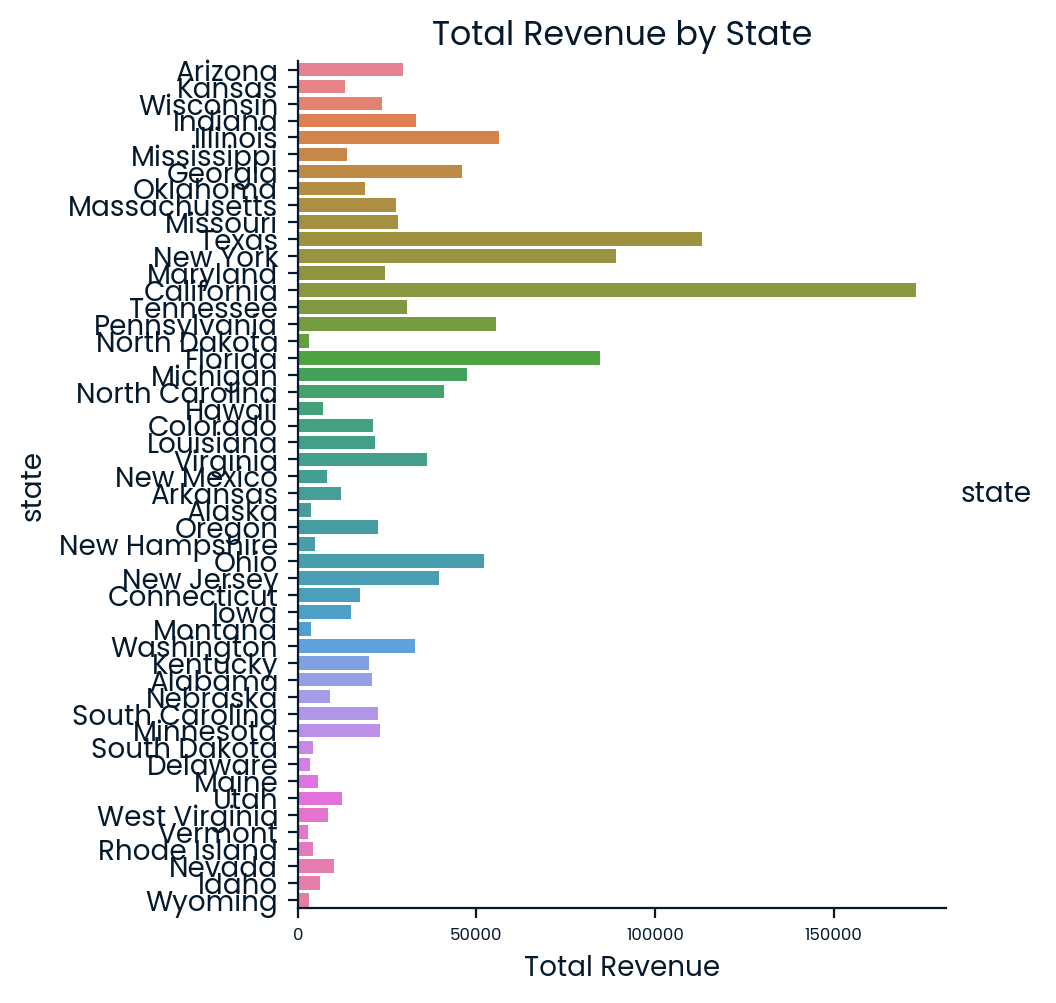

In [17]:
st_r =df.groupby('state')['revenue'].sum().reset_index()
st_r_s = st_r.sort_values(by='revenue',ascending=False)
print(st_r_s)
sns.catplot(data=df, y='state', x='revenue', hue='state', estimator=sum,kind='bar', ci=None)
plt.xticks( fontsize=6)
plt.title("Total Revenue by State")
plt.xlabel("Total Revenue")
plt.show()

## Relationship Between Site Visits and Sales

To understand the relationship between website activity and sales performance, I plotted a Seaborn jointplot with a regression line between the variables nb_site_visits (number of site visits) and nb_sold (number of units sold).

**Findings:**

- The regression line indicates a positive correlation between the number of site visits and the number of sales.

- As the number of site visits increases, the number of units sold also tends to increase.

- This relationship supports the idea that higher customer engagement (more site visits) leads to greater sales performance.

- The scatter distribution shows a fairly strong linear pattern, consistent with the earlier correlation coefficient (~0.81) observed between these two variables in the heatmap.

**Interpretation:**
This insight suggests that marketing efforts that drive more traffic to the website could directly contribute to increased sales volume. The business should consider optimizing digital campaigns and user experience to sustain or enhance this relationship.

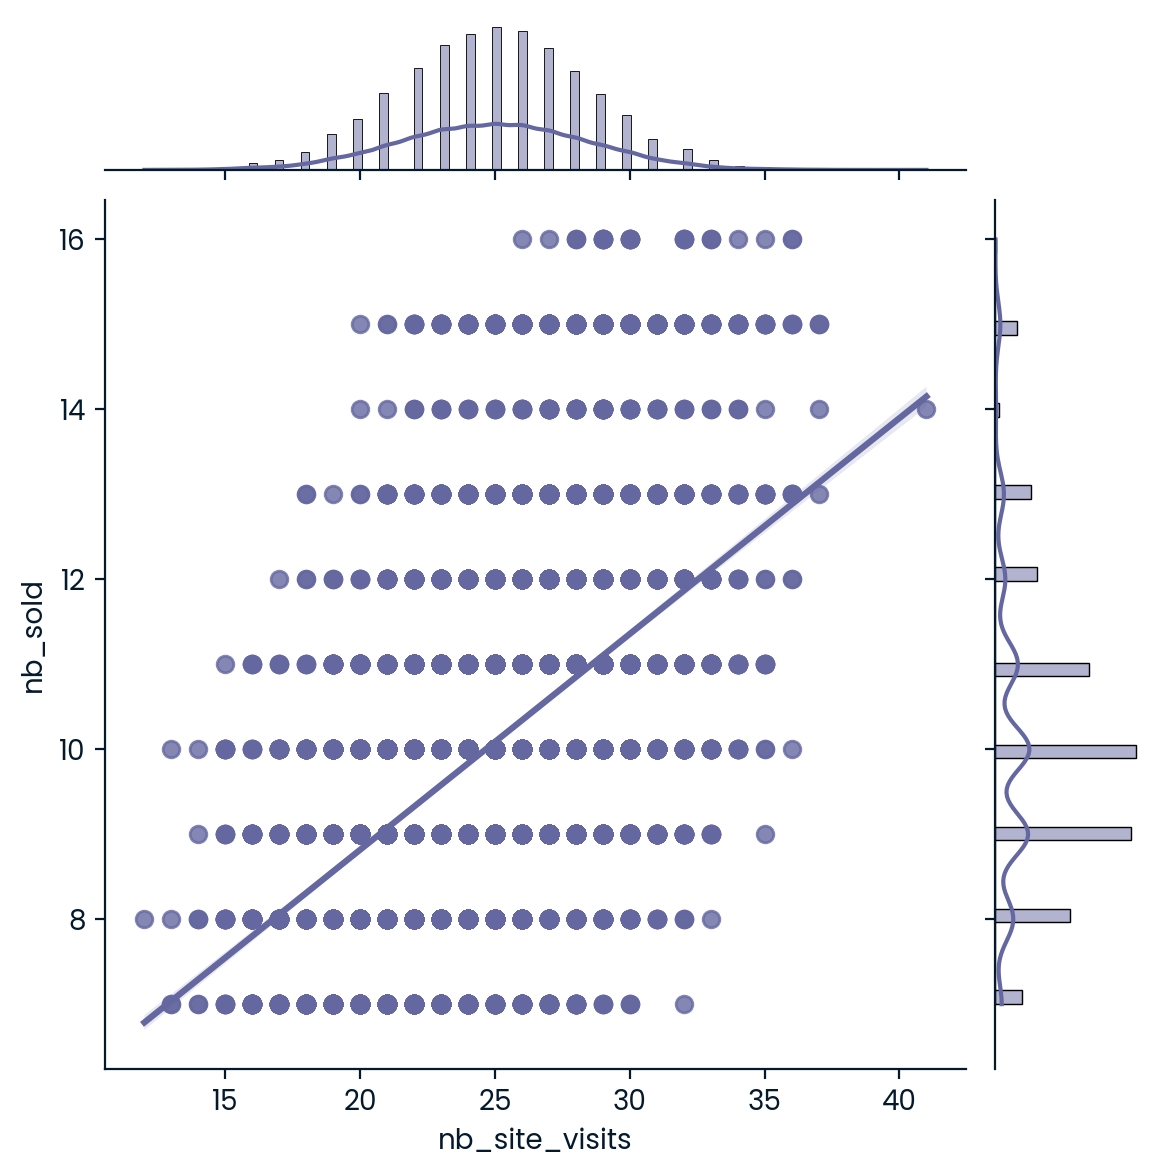

In [18]:
sns.jointplot(data=df, x='nb_site_visits', y='nb_sold', kind='reg')

## Revenue Distribution

To understand how revenue values are distributed, I plotted a histogram with 30 bins using Seaborn’s histplot() function.

**Findings:**

- The revenue distribution is right-skewed, meaning most transactions generate lower revenue values, while a few customers contribute significantly higher revenue.

- The long tail on the right side of the histogram indicates the presence of high-value outliers (customers or deals with exceptionally large revenue).

- This skewness supports the earlier choice of using the median (instead of mean) for handling missing values in the revenue column.

- The KDE curve helps visualize the smooth distribution trend and confirms that most data points are concentrated in the lower range of revenue.

**Interpretation:**
This suggests that while a majority of customers produce modest revenue, a small segment generates high sales. The business could focus on identifying and retaining those high-value customers.

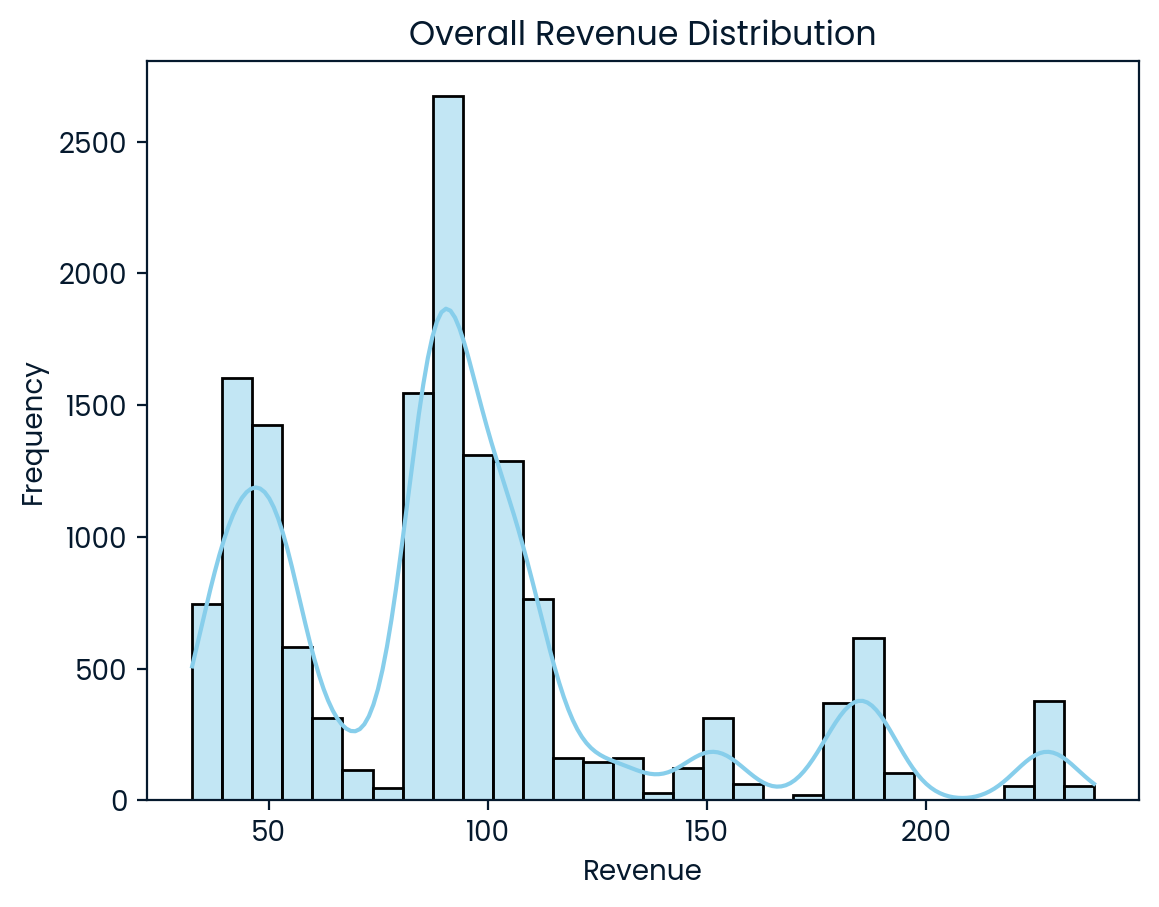

In [21]:
sns.histplot(df['revenue'], kde=True, bins=30, color='skyblue')
plt.title('Overall Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

## Weekly Revenue by Sales Method

To analyze how revenue changes over time for each sales approach, I grouped the data by week and sales method, and calculated the total revenue for each group:

**Findings:**

- The line plot shows weekly revenue trends for each sales method.

- The Email method generates the highest total revenue across most weeks.

- The Email + Call method, while less frequent, shows stable and consistent revenue per week, suggesting high-value conversions.

- The Call method shows lower revenue and more fluctuations, indicating lower efficiency.

**Interpretation:**

- The business can focus on Email + Call for high-value customers while maintaining Email for general outreach.

- Tracking weekly trends helps monitor changes in revenue performance and the effectiveness of each sales method over time.

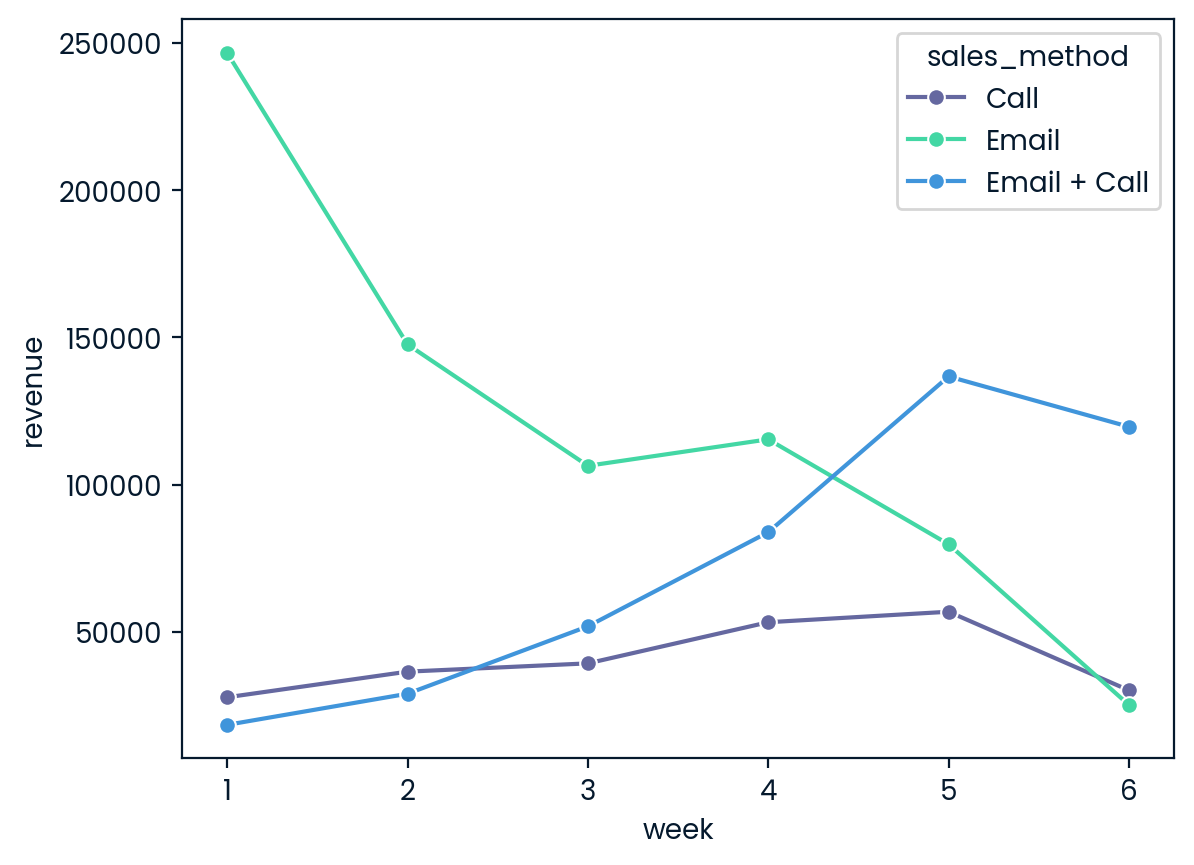

In [22]:
m = df.groupby(['week','sales_method'])['revenue'].sum().reset_index()

sns.lineplot(data=m, x='week', y='revenue', hue='sales_method', marker='o')
plt.show()

## Business Metric Definition
**Metric:** Average Revenue per Customer (ARPC) by Sales Method

**Purpose:**
The metric measures the average revenue generated per customer for each sales method.
This helps the business evaluate the effectiveness and efficiency of Email, Call, and Email + Call approaches.

**Formula:**

ARPC = Total Revenue per Sales Method / Number of Customers per Sales Method
​
How the business should monitor the metric

Track ARPC weekly or monthly for each sales method to see trends over time.

Compare ARPC across methods to identify high-performing methods.

Use the metric to allocate resources efficiently: prioritize methods that produce higher revenue per customer.

Visualize ARPC with bar charts or line charts to detect performance changes and seasonal patterns.

*Initial Values from Current Data*
|Sales Method |	Total Customers |	Total Revenue |	Average Revenue per Customer (ARPC)|
|-----|-----|-----|-----|
|Email|	7,466|	721,005.83|	96.54|
|Call|	4,962|	243,762.99|	49.13|
|Email + Call|	2,572|	439,492.19|	170.85|

**Interpretation:**

- Email + Call produces the highest revenue per customer (~171), making it most effective per client.

- Email reaches the most customers and generates the highest total revenue (~96 per customer), suitable for broad outreach.

- Call has the lowest ARPC (~49), indicating lower efficiency.

**Recommendation:**

- Use ARPC as a KPI to track method effectiveness over time.

- Focus resources on high ARPC methods (Email + Call) for premium customers.

- Continue Email-only campaigns for scale.

- Reduce time spent on low-performing Call-only outreach unless strategic reasons exist.